In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
import os

In [3]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.3, max_tokens=2000
    )

llm = get_groq_llm()

In [4]:
llm.invoke("hell")

AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 24, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.050264649, 'prompt_time': 0.004003786, 'completion_time': 0.144169798, 'total_time': 0.148173584}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3d587a02fb', 'id': 'chatcmpl-51c95b3f-a73e-41ce-be97-a20eb5ffb398', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3fac-9c9f-7dc1-9a60-f2accd7228d8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 44, 'total_tokens': 116, 'input_token_details': {}, 'output_token_details': {'reasoning': 24}})

In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str


In [6]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

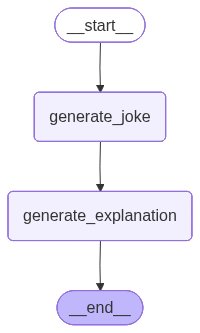

In [9]:
workflow

In [10]:
config1 = {"configurable": {"thread_id": "1"}}

In [11]:
workflow.invoke({'topic':'mumbai'}, config=config1)

{'topic': 'mumbai',
 'joke': 'Why don’t Mumbai’s traffic police ever play hide‑and‑seek?\n\nBecause good luck hiding when the city’s “traffic” is always “Mumbai‑tally” on the move!',
 'explanation': '**Why the joke works**\n\n1. **The set‑up**  \n   The question asks why Mumbai’s traffic police can’t play hide‑and‑seek.  \n   The answer immediately tells us the reason: the city’s traffic is *always* on the move.\n\n2. **The pun – “Mumbai‑tally”**  \n   - **“Mumbai”** is the city.  \n   - **“Tally”** means to count or keep a record.  \n   - When you say “Mumbai‑tally” it sounds like “Mumbai tally” – as if you’re counting the traffic in Mumbai.  \n   - The wordplay turns “Mumbai tally” into a playful, made‑up word that still hints at “Mumbai traffic is always on the move.”\n\n3. **Double meaning of “on the move”**  \n   - Literally, traffic is constantly moving through the streets.  \n   - Figuratively, it means the traffic is always active and changing, so there’s no place to hide.\n\n4

In [12]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'mumbai', 'joke': 'Why don’t Mumbai’s traffic police ever play hide‑and‑seek?\n\nBecause good luck hiding when the city’s “traffic” is always “Mumbai‑tally” on the move!', 'explanation': '**Why the joke works**\n\n1. **The set‑up**  \n   The question asks why Mumbai’s traffic police can’t play hide‑and‑seek.  \n   The answer immediately tells us the reason: the city’s traffic is *always* on the move.\n\n2. **The pun – “Mumbai‑tally”**  \n   - **“Mumbai”** is the city.  \n   - **“Tally”** means to count or keep a record.  \n   - When you say “Mumbai‑tally” it sounds like “Mumbai tally” – as if you’re counting the traffic in Mumbai.  \n   - The wordplay turns “Mumbai tally” into a playful, made‑up word that still hints at “Mumbai traffic is always on the move.”\n\n3. **Double meaning of “on the move”**  \n   - Literally, traffic is constantly moving through the streets.  \n   - Figuratively, it means the traffic is always active and changing, so there’s no 

In [13]:
config1 = {"configurable": {"thread_id": "1"}}

workflow.invoke({'topic':'nagpur'}, config=config1)

workflow.get_state(config1)

StateSnapshot(values={'topic': 'nagpur', 'joke': 'Why did the orange go to Nagpur?  \nBecause it heard the city was the **“orange”** of the region and wanted to **“peel”** its way to the top!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it means | How it’s used in the joke |\n|---------|---------------|---------------------------|\n| **Nagpur** | A city in central India that’s famous for its high‑quality oranges. It’s often called the “orange capital” of India. | The punchline hinges on Nagpur’s reputation as the place where oranges are king. |\n| **“Orange” of the region** | A play on the phrase “the orange of the region” – literally the fruit that dominates the area, but also a pun on “orange” as a colour or a standout thing. | The joke says the city is “the orange” of the region, meaning it’s the most important orange‑producing place. |\n| **“Peel”** | To remove the skin of a fruit. It also sounds like “peel” as in “to peel away” or “to make progr

# ## Intermediate States

In [14]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'nagpur', 'joke': 'Why did the orange go to Nagpur?  \nBecause it heard the city was the **“orange”** of the region and wanted to **“peel”** its way to the top!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it means | How it’s used in the joke |\n|---------|---------------|---------------------------|\n| **Nagpur** | A city in central India that’s famous for its high‑quality oranges. It’s often called the “orange capital” of India. | The punchline hinges on Nagpur’s reputation as the place where oranges are king. |\n| **“Orange” of the region** | A play on the phrase “the orange of the region” – literally the fruit that dominates the area, but also a pun on “orange” as a colour or a standout thing. | The joke says the city is “the orange” of the region, meaning it’s the most important orange‑producing place. |\n| **“Peel”** | To remove the skin of a fruit. It also sounds like “peel” as in “to peel away” or “to make prog

In [15]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti break up with the lasagna?\n\nBecause it couldn’t handle the *layered* drama—it just wanted a *simple* noodle‑time!',
 'explanation': '**Why the joke works**\n\n| Element | What it’s playing on | Why it’s funny |\n|---------|----------------------|----------------|\n| **Spaghetti vs. Lasagna** | Two very different kinds of pasta. Spaghetti is a single, thin strand; lasagna is a stack of sheets, sauce, cheese, and meat. | The joke treats the two as if they were people in a romantic relationship, which is already a silly image. |\n| **“Break up”** | In everyday speech it means ending a romantic relationship. In cooking it can also mean “separate” or “split apart.” | The punchline uses the double meaning: the spaghetti “breaks up” with the lasagna both as a lover and as a piece of food. |\n| **“Layered drama”** | “Layered” refers to lasagna’s literal layers of pasta, sauce, and cheese. “Drama” refers to emotional complexity in a relations

In [16]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the lasagna?\n\nBecause it couldn’t handle the *layered* drama—it just wanted a *simple* noodle‑time!', 'explanation': '**Why the joke works**\n\n| Element | What it’s playing on | Why it’s funny |\n|---------|----------------------|----------------|\n| **Spaghetti vs. Lasagna** | Two very different kinds of pasta. Spaghetti is a single, thin strand; lasagna is a stack of sheets, sauce, cheese, and meat. | The joke treats the two as if they were people in a romantic relationship, which is already a silly image. |\n| **“Break up”** | In everyday speech it means ending a romantic relationship. In cooking it can also mean “separate” or “split apart.” | The punchline uses the double meaning: the spaghetti “breaks up” with the lasagna both as a lover and as a piece of food. |\n| **“Layered drama”** | “Layered” refers to lasagna’s literal layers of pasta, sauce, and cheese. “Drama” refers to emotional comple

In [17]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the lasagna?\n\nBecause it couldn’t handle the *layered* drama—it just wanted a *simple* noodle‑time!', 'explanation': '**Why the joke works**\n\n| Element | What it’s playing on | Why it’s funny |\n|---------|----------------------|----------------|\n| **Spaghetti vs. Lasagna** | Two very different kinds of pasta. Spaghetti is a single, thin strand; lasagna is a stack of sheets, sauce, cheese, and meat. | The joke treats the two as if they were people in a romantic relationship, which is already a silly image. |\n| **“Break up”** | In everyday speech it means ending a romantic relationship. In cooking it can also mean “separate” or “split apart.” | The punchline uses the double meaning: the spaghetti “breaks up” with the lasagna both as a lover and as a piece of food. |\n| **“Layered drama”** | “Layered” refers to lasagna’s literal layers of pasta, sauce, and cheese. “Drama” refers to emotional compl

# ### Time Travel
# 
# ## we can go back to any previous node to do the execution again for debugging & changing the input as well


## so let's go to the pizza example where we got the topic & we want to go back to joke generation step & further steps.
## In order to do that we need to grab the checkpoint id where we got the topic. We can get it from the state history.


In [18]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the lasagna?\n\nBecause it couldn’t handle the *layered* drama—it just wanted a *simple* noodle‑time!', 'explanation': '**Why the joke works**\n\n| Element | What it’s playing on | Why it’s funny |\n|---------|----------------------|----------------|\n| **Spaghetti vs. Lasagna** | Two very different kinds of pasta. Spaghetti is a single, thin strand; lasagna is a stack of sheets, sauce, cheese, and meat. | The joke treats the two as if they were people in a romantic relationship, which is already a silly image. |\n| **“Break up”** | In everyday speech it means ending a romantic relationship. In cooking it can also mean “separate” or “split apart.” | The punchline uses the double meaning: the spaghetti “breaks up” with the lasagna both as a lover and as a piece of food. |\n| **“Layered drama”** | “Layered” refers to lasagna’s literal layers of pasta, sauce, and cheese. “Drama” refers to emotional compl

In [19]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f153696-d662-6a92-8000-71e93f52cfc4"}}) ## checkpoint id from pizza run where we haver the topic but we need to generate the joke


StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f153696-d662-6a92-8000-71e93f52cfc4'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-19T09:59:29.727963+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153696-d65e-6d01-bfff-74831d33d2ba'}}, tasks=(PregelTask(id='fa218d28-7a49-f00d-9d0b-927fbe526b9e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the spaghetti break up with the lasagna?\n\nBecause it couldn’t handle the *layered* drama—it just wanted a *simple* noodle‑time!'}),), interrupts=())

In [20]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f153696-d662-6a92-8000-71e93f52cfc4"}})


{'topic': 'pasta',
 'joke': 'Why did the spaghetti start a band?  \nBecause it wanted to *pasta* the beat and *noodle* around the rhythm!',
 'explanation': '**Why the joke works – a quick word‑play breakdown**\n\n| Part of the joke | What it’s doing | Why it’s funny |\n|------------------|-----------------|----------------|\n| **“Why did the spaghetti start a band?”** | Sets up a classic “Why did X do Y?” question that usually leads to a pun or a silly answer. | The listener expects a logical answer, but the punchline will twist it into a play on words. |\n| **“Because it wanted to *pasta* the beat”** | *Pasta* is a homophone of “pass” (as in “pass the beat”) and also the name of the food. | The humor comes from treating the food as if it could *play* music. The word *pasta* is used in two senses at once: the literal food and the idea of “passing” or “playing” a beat. |\n| **“and *noodle* around the rhythm!”** | *Noodle* is both a type of pasta and a verb meaning “to fumble, play aroun

In [21]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti start a band?  \nBecause it wanted to *pasta* the beat and *noodle* around the rhythm!', 'explanation': '**Why the joke works – a quick word‑play breakdown**\n\n| Part of the joke | What it’s doing | Why it’s funny |\n|------------------|-----------------|----------------|\n| **“Why did the spaghetti start a band?”** | Sets up a classic “Why did X do Y?” question that usually leads to a pun or a silly answer. | The listener expects a logical answer, but the punchline will twist it into a play on words. |\n| **“Because it wanted to *pasta* the beat”** | *Pasta* is a homophone of “pass” (as in “pass the beat”) and also the name of the food. | The humor comes from treating the food as if it could *play* music. The word *pasta* is used in two senses at once: the literal food and the idea of “passing” or “playing” a beat. |\n| **“and *noodle* around the rhythm!”** | *Noodle* is both a type of pasta and a verb meaning “t

# ## now we can see more Snapshots due to the re-execution

In [22]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'nagpur', 'joke': 'Why did the orange go to Nagpur?  \nBecause it heard the city was the **“orange”** of the region and wanted to **“peel”** its way to the top!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it means | How it’s used in the joke |\n|---------|---------------|---------------------------|\n| **Nagpur** | A city in central India that’s famous for its high‑quality oranges. It’s often called the “orange capital” of India. | The punchline hinges on Nagpur’s reputation as the place where oranges are king. |\n| **“Orange” of the region** | A play on the phrase “the orange of the region” – literally the fruit that dominates the area, but also a pun on “orange” as a colour or a standout thing. | The joke says the city is “the orange” of the region, meaning it’s the most important orange‑producing place. |\n| **“Peel”** | To remove the skin of a fruit. It also sounds like “peel” as in “to peel away” or “to make prog

# #### Updating State

In [27]:
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f153696-d662-6a92-8000-71e93f52cfc4", "checkpoint_ns": ""}}, {'topic':'gulab jamun'})


{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1536b7-4ccb-6a17-8001-31b12526c0b6'}}

# ## now we have updated the state with topic as samosa, one more snapshot will be created

In [28]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'gulab jamun'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1536b7-4ccb-6a17-8001-31b12526c0b6'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-19T10:14:01.137615+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153696-d662-6a92-8000-71e93f52cfc4'}}, tasks=(PregelTask(id='14bf91bd-f10f-d3cb-fadf-149c0f3439f7', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1536a7-3664-61a9-8001-302bfd293cad'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-19T10:06:49.291613+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoi

# ## and to execute the workflow from the updated state (samosa) we need to pass the checkpoint id of samosa snapshot



In [29]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f1536b7-4ccb-6a17-8001-31b12526c0b6"}})


{'topic': 'gulab jamun',
 'joke': 'Why did the gulab jamun start a dating app?\n\nBecause it heard that “sugar‑coated hearts” were the best way to find a *sweet* match!',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|---------------------------------|\n| **Gulab jamun** | A popular Indian dessert: deep‑fried dough balls soaked in a sweet syrup. | It’s literally “sweet” in every sense—taste, texture, and even the word “sweet” itself. |\n| **Dating app** | A modern way to meet people online. | The joke sets up a scenario that’s absurd: a dessert, not a person, deciding to use a dating app. |\n| **“Sugar‑coated hearts”** | A playful phrase that could mean: <br>1. Hearts (as in romantic feelings) that are literally coated in sugar. <br>2. A metaphor for “sweet love.” | The double meaning is the core of the pun. |\n| **“Sweet match”** | A phrase that means: <br>1. A good romantic pairing. <b

In [30]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'gulab jamun', 'joke': 'Why did the gulab jamun start a dating app?\n\nBecause it heard that “sugar‑coated hearts” were the best way to find a *sweet* match!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|---------------------------------|\n| **Gulab jamun** | A popular Indian dessert: deep‑fried dough balls soaked in a sweet syrup. | It’s literally “sweet” in every sense—taste, texture, and even the word “sweet” itself. |\n| **Dating app** | A modern way to meet people online. | The joke sets up a scenario that’s absurd: a dessert, not a person, deciding to use a dating app. |\n| **“Sugar‑coated hearts”** | A playful phrase that could mean: <br>1. Hearts (as in romantic feelings) that are literally coated in sugar. <br>2. A metaphor for “sweet love.” | The double meaning is the core of the pun. |\n| **“Sweet match”** | A phrase that means: <br>1. A good 

# ### Fault Tolerance kind of similar as human in the loop (In HITL we do it perpupose fully using langraph interrupt)

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [ ]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}


In [ ]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
graph

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")


In [ ]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

In [ ]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)



In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))